<a href="https://colab.research.google.com/github/ArpulaAnjali/B19_1319/blob/main/papercode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 533
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 15
[LightGBM] [Info] Start training from score 7.728275
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ MODEL ACCURACY COMPARISON
Random Forest R²: -0.015 | MAE: 3.950
XGBoost       R²: -0.342 | MAE: 4.380
LightGBM      R²: -0.329 | MAE: 4.279
🔥 Best model is: Random Forest


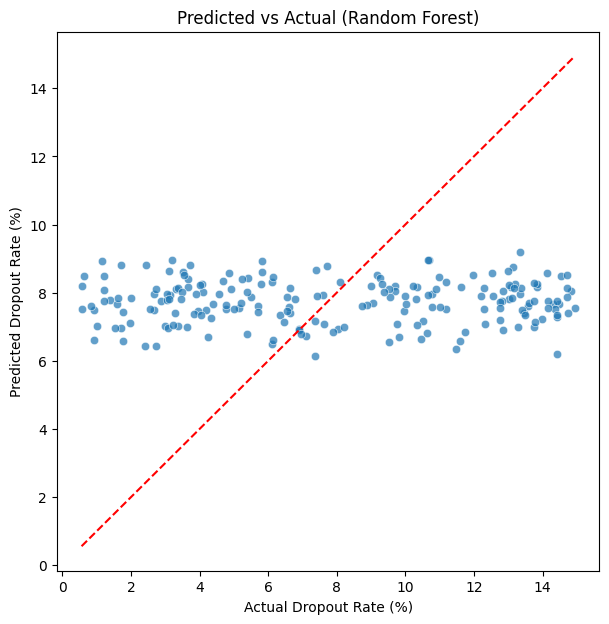

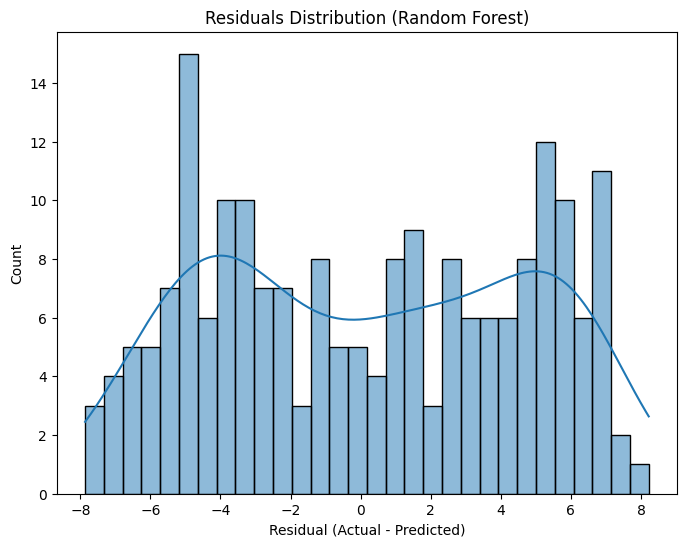

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import numpy as np

# Extra Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Load dataset
data = pd.read_csv('educational_inequality.csv')

# Features & Target
features = data[['percent_low_income', 'funding_per_student_usd', 'grade_level', 'state']]
target = data['dropout_rate_percent']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Preprocessing
numeric_features = ['percent_low_income', 'funding_per_student_usd']
categorical_features = ['grade_level', 'state']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# -------------------
# RANDOM FOREST
# -------------------
rf = RandomForestRegressor(random_state=42)
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', rf)])

param_dist = {
    'regressor__n_estimators': randint(200, 600),
    'regressor__max_depth': randint(10, 50),
    'regressor__min_samples_split': randint(2, 15),
    'regressor__min_samples_leaf': randint(1, 8),
    'regressor__max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)
y_pred_rf = random_search_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# -------------------
# XGBOOST
# -------------------
xgb = XGBRegressor(random_state=42, n_estimators=500, learning_rate=0.05, max_depth=6)
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', xgb)])
pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# -------------------
# LIGHTGBM
# -------------------
lgbm = LGBMRegressor(random_state=42, n_estimators=500, learning_rate=0.05, max_depth=-1)
pipeline_lgbm = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', lgbm)])
pipeline_lgbm.fit(X_train, y_train)

y_pred_lgbm = pipeline_lgbm.predict(X_test)
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

# -------------------
# ACCURACY REPORT
# -------------------
print("="*45)
print("✅ MODEL ACCURACY COMPARISON")
print("="*45)
print(f"Random Forest R²: {r2_rf:.3f} | MAE: {mae_rf:.3f}")
print(f"XGBoost       R²: {r2_xgb:.3f} | MAE: {mae_xgb:.3f}")
print(f"LightGBM      R²: {r2_lgbm:.3f} | MAE: {mae_lgbm:.3f}")
print("="*45)

# -------------------
# VISUALIZATIONS
# -------------------

# 1. Predicted vs Actual for Best Model
best_model_name = max(
    [("Random Forest", r2_rf, y_pred_rf), ("XGBoost", r2_xgb, y_pred_xgb), ("LightGBM", r2_lgbm, y_pred_lgbm)],
    key=lambda x: x[1]
)[0]

print(f"🔥 Best model is: {best_model_name}")

if best_model_name == "Random Forest":
    y_pred_best = y_pred_rf
elif best_model_name == "XGBoost":
    y_pred_best = y_pred_xgb
else:
    y_pred_best = y_pred_lgbm

plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Dropout Rate (%)")
plt.ylabel("Predicted Dropout Rate (%)")
plt.title(f"Predicted vs Actual ({best_model_name})")
plt.show()

# 2. Residuals Plot
residuals = y_test - y_pred_best
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title(f"Residuals Distribution ({best_model_name})")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()